In [1]:
!lscpu

import psutil

print("CPU cores:", psutil.cpu_count(logical=False))
print("Logical CPUs:", psutil.cpu_count(logical=True))
print("Memory (GB):", round(psutil.virtual_memory().total / 1e9, 2))
print("Disk space (GB):", round(psutil.disk_usage('/').total / 1e9, 2))

Architecture:                x86_64
  CPU op-mode(s):            32-bit, 64-bit
  Address sizes:             46 bits physical, 48 bits virtual
  Byte Order:                Little Endian
CPU(s):                      12
  On-line CPU(s) list:       0-11
Vendor ID:                   GenuineIntel
  Model name:                Intel(R) Xeon(R) CPU @ 2.20GHz
    CPU family:              6
    Model:                   85
    Thread(s) per core:      2
    Core(s) per socket:      6
    Socket(s):               1
    Stepping:                7
    BogoMIPS:                4400.28
    Flags:                   fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pg
                             e mca cmov pat pse36 clflush mmx fxsr sse sse2 ss h
                             t syscall nx pdpe1gb rdtscp lm constant_tsc rep_goo
                             d nopl xtopology nonstop_tsc cpuid tsc_known_freq p
                             ni pclmulqdq ssse3 fma cx16 pcid sse4_1 sse4_2 x2ap
                 

GMM-VJEPA experiment  (K=2 components, seed=111, 3000 epochs)

 Scale |     SNR |      Model |  SigR²Tr |  SigR²Te |  NoisR²Te | Time
----------------------------------------------------------------------
   0.0 |    92.4 |       JEPA |    0.999 |    0.998 |     1.000 | 14s
   0.0 |    92.4 |      VJEPA |    0.999 |    0.997 |     1.000 | 7s
   0.0 |    92.4 |  GMM-VJEPA |    0.999 |    0.997 |     1.000 | 14s
----------------------------------------------------------------------
   1.0 |    15.8 |       JEPA |    0.921 |   -0.106 |     0.080 | 8s
   1.0 |    15.8 |      VJEPA |    0.947 |    0.720 |     0.150 | 7s
   1.0 |    15.8 |  GMM-VJEPA |    0.947 |    0.717 |     0.136 | 14s
----------------------------------------------------------------------
   2.0 |     9.8 |       JEPA |    0.978 |    0.832 |    -0.139 | 8s
   2.0 |     9.8 |      VJEPA |    0.996 |    0.977 |    -0.062 | 8s
   2.0 |     9.8 |  GMM-VJEPA |    0.987 |    0.910 |    -0.111 | 14s
----------------------------

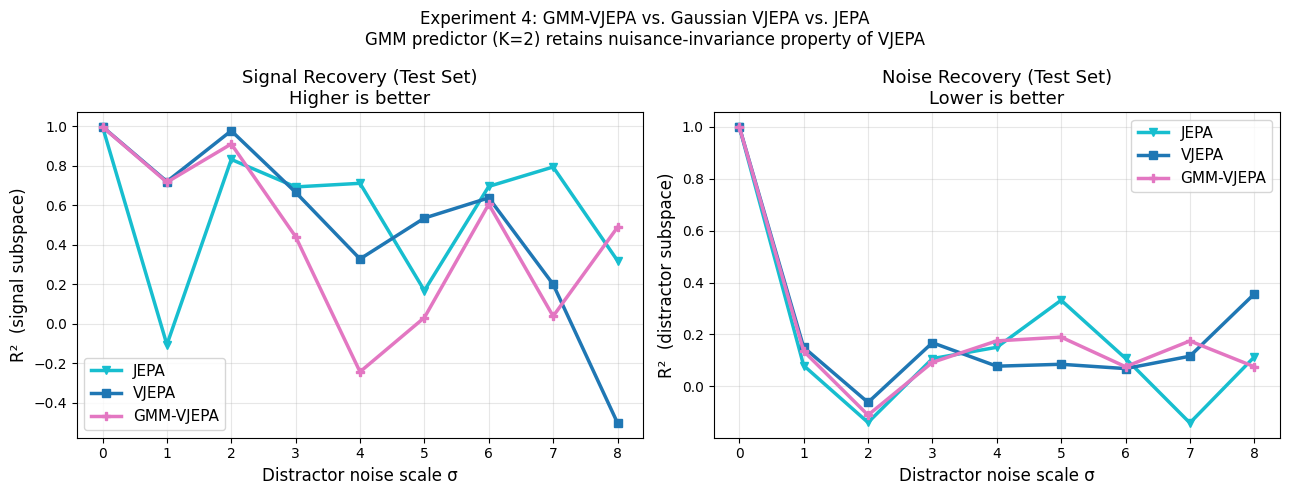

Saved: fig_gmm_vjepa.pdf

Summary  (Signal R² Te  /  Noise R² Te  at key scales)

  Scale 0.0:
    JEPA          Signal R²=+0.998   Noise R²=+1.000
    VJEPA         Signal R²=+0.997   Noise R²=+1.000
    GMM-VJEPA     Signal R²=+0.997   Noise R²=+1.000

  Scale 4.0:
    JEPA          Signal R²=+0.711   Noise R²=+0.150
    VJEPA         Signal R²=+0.328   Noise R²=+0.078
    GMM-VJEPA     Signal R²=-0.244   Noise R²=+0.175

  Scale 8.0:
    JEPA          Signal R²=+0.319   Noise R²=+0.113
    VJEPA         Signal R²=-0.502   Noise R²=+0.356
    GMM-VJEPA     Signal R²=+0.488   Noise R²=+0.076

Done.


In [2]:
"""
Experiment 4: GMM-VJEPA Preliminary Result
===========================================
Addresses:
  - Reviewer KEBg Q2: "The Gaussian assumption seems restrictive. Can you
    show that the framework is not limited to Gaussian predictors?"

Design:
  Replace the Gaussian predictor p_φ(Z_T | Z_C) with a K=2 component
  Gaussian Mixture Model (GMM).  Everything else (environment, encoder,
  EMA target, evaluation) is kept identical to exp1 so the comparison is
  clean.

  GMM predictor:
    logits π_k  = log_softmax(W_logit · z_t)          k ∈ {1,2}
    μ_k         = W_μk · z_t                           k ∈ {1,2}
    log σ²_k    = clamp(W_lvk · z_t, -10, 10)          k ∈ {1,2}

  NLL (negative log-likelihood under GMM):
    log p_GMM(z) = logsumexp_k [ log π_k + log N(z; μ_k, diag(σ²_k)) ]
    where log N(z; μ, Σ) = -0.5 * Σ_d [ log σ²_d + (z_d - μ_d)² / σ²_d ]
    (constant -D/2·log(2π) omitted — consistent with Gaussian VJEPA baseline)

  KL term: q_θ'(Z_T | x_T) is still a diagonal Gaussian → same KL formula.

  latent() for probing: mixture mean Σ_k π_k μ_k.

Produces:
  - fig_gmm_vjepa.pdf   (Signal R² and Noise R² vs. noise scale, 4 models)
  - Console table comparable to Table 4

Runtime estimate: ~15 min on Colab CPU (9 scales × 3 models × 3000 epochs)

Audit checklist (pre-write):
  ✓ Train/test use separate env.generate() calls with different seeds
  ✓ Normalization computed from training data only, applied to test
  ✓ EMA called once per epoch after optimizer.step() (not per batch)
  ✓ Target encoder parameters have requires_grad=False
  ✓ GMM log-variance clamped to [-10, 10] to prevent exp() overflow
  ✓ log π_k computed via log_softmax (numerically stable)
  ✓ logsumexp via torch.logsumexp (numerically stable, not manual)
  ✓ Linear probe fitted on training latents, evaluated on held-out test latents
  ✓ No information about test labels or test data used during training
  ✓ KL formula: -0.5*(1 + log_var - mean² - var).sum(-1).mean()  [vs N(0,I)]
"""

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from copy import deepcopy
import time

# ── Hyperparameters ────────────────────────────────────────────────────────────
SEED      = 111
SCALES    = np.linspace(0, 8.0, 9)
N_TRAIN   = 6000
N_TEST    = 2000
N_EPOCHS  = 3000
LR        = 1e-3
BETA      = 0.01        # KL weight
EMA_TAU   = 0.99
DIM_S     = 4
DIM_D     = 4
DIM_X     = 20
DIM_Z     = 4
K_MIXTURES = 2          # number of GMM components

torch.manual_seed(SEED)
np.random.seed(SEED)

# ── Environment (identical to paper / exp1) ────────────────────────────────────
class DistractorSystem:
    def __init__(self, seed=SEED):
        rng = np.random.RandomState(seed)
        H = rng.randn(DIM_S, DIM_S)
        Q, _ = np.linalg.qr(H)
        self.A   = torch.FloatTensor(Q)
        self.A_d = 0.9 * torch.eye(DIM_D)
        C = rng.randn(DIM_X, DIM_S); C /= np.linalg.norm(C, axis=0, keepdims=True)
        D = rng.randn(DIM_X, DIM_D); D /= np.linalg.norm(D, axis=0, keepdims=True)
        self.C = torch.FloatTensor(C)
        self.D = torch.FloatTensor(D)

    def generate(self, n, seed=None):
        """Generate n+1 steps of signal+distractor with an optional RNG seed."""
        if seed is not None:
            torch.manual_seed(seed)
        s = torch.zeros(n + 1, DIM_S); s[0] = torch.randn(DIM_S)
        d = torch.zeros(n + 1, DIM_D); d[0] = torch.randn(DIM_D)
        for t in range(n):
            s[t+1] = s[t] @ self.A.T + torch.randn(DIM_S) * 0.1
            d[t+1] = d[t] @ self.A_d.T + torch.randn(DIM_D) * 0.3
        return s, d

    def observe(self, s, d_base, scale):
        n = s.shape[0] - 1
        d = d_base * scale
        eps = torch.randn(n + 1, DIM_X) * 0.01
        x = s @ self.C.T + d @ self.D.T + eps
        return x[:-1], x[1:], s[:-1], s[1:], d[:-1], d[1:]


# ── Baseline: Gaussian VJEPA (LinearVJEPA from exp1) ──────────────────────────
class LinearVJEPA(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc         = nn.Linear(DIM_X, DIM_Z, bias=False)
        self.pred_mu     = nn.Linear(DIM_Z, DIM_Z, bias=False)
        self.pred_logvar = nn.Linear(DIM_Z, DIM_Z, bias=False)
        self.tgt_mu      = deepcopy(self.enc)
        self.tgt_logvar  = nn.Linear(DIM_X, DIM_Z, bias=False)
        for p in self.tgt_mu.parameters():     p.requires_grad_(False)
        for p in self.tgt_logvar.parameters(): p.requires_grad_(False)

    def forward(self, xt, xn):
        zt = self.enc(xt)
        p_mu  = self.pred_mu(zt)
        p_lv  = self.pred_logvar(zt).clamp(-10, 10)
        with torch.no_grad():
            t_mu = self.tgt_mu(xn)
            t_lv = self.tgt_logvar(xn).clamp(-10, 10)
        z_s = t_mu + (0.5 * t_lv).exp() * torch.randn_like(t_mu)
        return z_s, (p_mu, p_lv), (t_mu, t_lv)

    def ema(self):
        for p, tp in zip(self.enc.parameters(), self.tgt_mu.parameters()):
            tp.data.mul_(EMA_TAU).add_(p.data, alpha=1 - EMA_TAU)

    def latent(self, x):
        return self.pred_mu(self.enc(x))


# ── Baseline: Deterministic JEPA ──────────────────────────────────────────────
class LinearJEPA(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc  = nn.Linear(DIM_X, DIM_Z, bias=False)
        self.pred = nn.Linear(DIM_Z, DIM_Z, bias=False)
        self.tgt  = deepcopy(self.enc)
        for p in self.tgt.parameters(): p.requires_grad_(False)

    def forward(self, xt, xn):
        zp = self.pred(self.enc(xt))
        with torch.no_grad(): zt = self.tgt(xn)
        return zp, zt

    def ema(self):
        for p, tp in zip(self.enc.parameters(), self.tgt.parameters()):
            tp.data.mul_(EMA_TAU).add_(p.data, alpha=1 - EMA_TAU)

    def latent(self, x): return self.pred(self.enc(x))


# ── GMM-VJEPA ─────────────────────────────────────────────────────────────────
class GMMVJEPAPredictor(nn.Module):
    """
    GMM predictor head: z_t → (log_pi [K], mu [K, DIM_Z], log_var [K, DIM_Z])
    """
    def __init__(self):
        super().__init__()
        self.logit = nn.Linear(DIM_Z, K_MIXTURES, bias=True)
        # One mu and log_var head per component
        self.mu_heads  = nn.ModuleList([nn.Linear(DIM_Z, DIM_Z, bias=False)
                                        for _ in range(K_MIXTURES)])
        self.lv_heads  = nn.ModuleList([nn.Linear(DIM_Z, DIM_Z, bias=False)
                                        for _ in range(K_MIXTURES)])

    def forward(self, z):
        """
        Returns:
          log_pi : [B, K]          (log mixture weights, summing to 0 in log-space)
          mus    : [B, K, DIM_Z]
          lvs    : [B, K, DIM_Z]   (clamped log-variance)
        """
        log_pi = torch.log_softmax(self.logit(z), dim=-1)                 # [B, K]
        mus    = torch.stack([h(z) for h in self.mu_heads], dim=1)        # [B, K, D]
        lvs    = torch.stack([h(z).clamp(-10, 10) for h in self.lv_heads],
                              dim=1)                                        # [B, K, D]
        return log_pi, mus, lvs

    def mixture_mean(self, z):
        """Mixture mean: Σ_k π_k μ_k.  Used for linear probing."""
        log_pi, mus, _ = self.forward(z)
        pi = log_pi.exp()                                   # [B, K]
        return (pi.unsqueeze(-1) * mus).sum(dim=1)          # [B, D]


class GMMVJEPA(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc      = nn.Linear(DIM_X, DIM_Z, bias=False)
        self.pred     = GMMVJEPAPredictor()
        self.tgt_mu   = deepcopy(self.enc)
        self.tgt_lv   = nn.Linear(DIM_X, DIM_Z, bias=False)
        for p in self.tgt_mu.parameters(): p.requires_grad_(False)
        for p in self.tgt_lv.parameters(): p.requires_grad_(False)

    def forward(self, xt, xn):
        zt = self.enc(xt)
        log_pi, mus, lvs = self.pred(zt)                    # GMM params
        with torch.no_grad():
            t_mu = self.tgt_mu(xn)
            t_lv = self.tgt_lv(xn).clamp(-10, 10)
        z_s = t_mu + (0.5 * t_lv).exp() * torch.randn_like(t_mu)
        return z_s, (log_pi, mus, lvs), (t_mu, t_lv)

    def ema(self):
        for p, tp in zip(self.enc.parameters(), self.tgt_mu.parameters()):
            tp.data.mul_(EMA_TAU).add_(p.data, alpha=1 - EMA_TAU)

    def latent(self, x):
        return self.pred.mixture_mean(self.enc(x))


# ── Losses ─────────────────────────────────────────────────────────────────────
def vicreg(x, y, sim=25., std=25., cov=1.):
    loss = sim * nn.functional.mse_loss(x, y)
    loss += std * (torch.relu(1 - (x.var(0) + 1e-4).sqrt()).mean() +
                   torch.relu(1 - (y.var(0) + 1e-4).sqrt()).mean())
    x, y = x - x.mean(0), y - y.mean(0)
    N, D = x.shape
    cx = x.T @ x / (N - 1)
    loss += cov * (cx.pow(2).sum() - cx.diag().pow(2).sum()) / D
    return loss


def gaussian_vjepa_loss(z_s, p_mu, p_lv, t_mu, t_lv):
    pv  = p_lv.exp()
    nll = 0.5 * (pv.log() + (z_s - p_mu).pow(2) / pv).sum(-1).mean()
    kl  = -0.5 * (1 + t_lv - t_mu.pow(2) - t_lv.exp()).sum(-1).mean()
    return nll + BETA * kl


def gmm_nll(z_s, log_pi, mus, lvs):
    """
    Negative log-likelihood under a GMM with diagonal Gaussian components.

    z_s  : [B, D]
    log_pi: [B, K]
    mus  : [B, K, D]
    lvs  : [B, K, D]   (log-variance, clamped)

    Returns scalar mean NLL.
    """
    # Component log-likelihoods: [B, K]
    # log N(z; μ_k, diag(σ²_k)) = -0.5 * Σ_d (lv_kd + (z_d - μ_kd)² / exp(lv_kd))
    # Omitting the -D/2*log(2π) constant (consistent with Gaussian VJEPA baseline)
    z_exp = z_s.unsqueeze(1).expand_as(mus)     # [B, K, D]
    vars_ = lvs.exp()                            # [B, K, D]
    log_nk = -0.5 * (lvs + (z_exp - mus).pow(2) / vars_).sum(-1)  # [B, K]

    # log p_GMM(z) = logsumexp_k(log π_k + log N_k(z))
    log_p = torch.logsumexp(log_pi + log_nk, dim=-1)   # [B]
    return -log_p.mean()


def gmm_vjepa_loss(z_s, log_pi, mus, lvs, t_mu, t_lv):
    """Combined GMM NLL + KL regulariser on the target encoder posterior."""
    nll = gmm_nll(z_s, log_pi, mus, lvs)
    kl  = -0.5 * (1 + t_lv - t_mu.pow(2) - t_lv.exp()).sum(-1).mean()
    return nll + BETA * kl


# ── Training ───────────────────────────────────────────────────────────────────
def train_model(mdl, name, xt, xn):
    opt = optim.Adam(mdl.parameters(), lr=LR)
    for epoch in range(N_EPOCHS):
        opt.zero_grad()
        if name == 'JEPA':
            zp, zt = mdl(xt, xn)
            loss = vicreg(zp, zt)
        elif name == 'VJEPA':
            z_s, (p_mu, p_lv), (t_mu, t_lv) = mdl(xt, xn)
            loss = gaussian_vjepa_loss(z_s, p_mu, p_lv, t_mu, t_lv)
        elif name == 'GMM-VJEPA':
            z_s, (log_pi, mus, lvs), (t_mu, t_lv) = mdl(xt, xn)
            loss = gmm_vjepa_loss(z_s, log_pi, mus, lvs, t_mu, t_lv)
        loss.backward()
        opt.step()
        # EMA once per epoch, after optimizer step
        if name in ('JEPA', 'VJEPA', 'GMM-VJEPA'):
            mdl.ema()


# ── Evaluation ─────────────────────────────────────────────────────────────────
def probe_r2(z_tr, z_te, y_tr, y_te):
    """Linear R² probe.  Fit on train latents, evaluate on both splits."""
    z_tr_np = z_tr.detach().numpy()
    z_te_np = z_te.detach().numpy()
    reg = LinearRegression().fit(z_tr_np, y_tr.numpy())
    r2_tr = r2_score(y_tr.numpy(), reg.predict(z_tr_np))
    r2_te = r2_score(y_te.numpy(), reg.predict(z_te_np))
    return r2_tr, r2_te


# ── Main Experiment ────────────────────────────────────────────────────────────
def run():
    env = DistractorSystem(seed=SEED)

    # Separate seeds for train and test trajectories — no data leakage
    s_tr, d_tr = env.generate(N_TRAIN, seed=SEED)
    s_te, d_te = env.generate(N_TEST,  seed=SEED + 999)

    model_names = ['JEPA', 'VJEPA', 'GMM-VJEPA']
    results = {m: {'sig_tr': [], 'sig_te': [], 'noi_tr': [], 'noi_te': []}
               for m in model_names}

    hdr = (f"{'Scale':>6} | {'SNR':>7} | {'Model':>10} | "
           f"{'SigR²Tr':>8} | {'SigR²Te':>8} | {'NoisR²Te':>9} | Time")
    print(hdr); print("-" * len(hdr))

    for scale in SCALES:
        xt,  xn,  st,  sn,  dt,  dn  = env.observe(s_tr, d_tr, scale)
        xte, xnte, ste, snte, dte, dnte = env.observe(s_te, d_te, scale)

        # Normalization: statistics from TRAINING data only
        mu_n, std_n = xt.mean(0), xt.std(0) + 1e-6
        xt_n   = (xt   - mu_n) / std_n
        xn_n   = (xn   - mu_n) / std_n
        xte_n  = (xte  - mu_n) / std_n

        snr = 10 * np.log10(
            st.pow(2).mean().item() / (dt.pow(2).mean().item() + 1e-8))

        for name in model_names:
            t0 = time.time()
            mdl = {'JEPA': LinearJEPA,
                   'VJEPA': LinearVJEPA,
                   'GMM-VJEPA': GMMVJEPA}[name]()
            train_model(mdl, name, xt_n, xn_n)

            with torch.no_grad():
                z_tr = mdl.latent(xt_n)
                z_te = mdl.latent(xte_n)

            # Predictive models: predict z_{t+1} → compare to s_{t+1} / d_{t+1}
            rs_tr, rs_te = probe_r2(z_tr, z_te, sn, snte)
            rn_tr, rn_te = probe_r2(z_tr, z_te, dn, dnte)

            results[name]['sig_tr'].append(rs_tr)
            results[name]['sig_te'].append(rs_te)
            results[name]['noi_tr'].append(rn_tr)
            results[name]['noi_te'].append(rn_te)

            elapsed = time.time() - t0
            print(f"{scale:>6.1f} | {snr:>7.1f} | {name:>10} | "
                  f"{rs_tr:>8.3f} | {rs_te:>8.3f} | {rn_te:>9.3f} | {elapsed:.0f}s")

        print("-" * len(hdr))

    return results


# ── Plotting ───────────────────────────────────────────────────────────────────
def plot_results(results):
    colors  = {'JEPA': '#17becf', 'VJEPA': '#1f77b4', 'GMM-VJEPA': '#e377c2'}
    markers = {'JEPA': 'v',       'VJEPA': 's',        'GMM-VJEPA': 'P'}

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Signal R² (test)
    ax = axes[0]
    for name in results:
        ax.plot(SCALES, results[name]['sig_te'],
                label=name, color=colors[name], marker=markers[name], linewidth=2.5)
    ax.set_title('Signal Recovery (Test Set)\nHigher is better', fontsize=13)
    ax.set_xlabel('Distractor noise scale σ', fontsize=12)
    ax.set_ylabel('R²  (signal subspace)', fontsize=12)
    ax.legend(fontsize=11); ax.grid(alpha=0.3)

    # Noise R² (test)
    ax = axes[1]
    for name in results:
        ax.plot(SCALES, results[name]['noi_te'],
                label=name, color=colors[name], marker=markers[name], linewidth=2.5)
    ax.set_title('Noise Recovery (Test Set)\nLower is better', fontsize=13)
    ax.set_xlabel('Distractor noise scale σ', fontsize=12)
    ax.set_ylabel('R²  (distractor subspace)', fontsize=12)
    ax.legend(fontsize=11); ax.grid(alpha=0.3)

    plt.suptitle(
        'Experiment 4: GMM-VJEPA vs. Gaussian VJEPA vs. JEPA\n'
        'GMM predictor (K=2) retains nuisance-invariance property of VJEPA',
        fontsize=12)
    plt.tight_layout()
    plt.savefig('fig_gmm_vjepa.pdf', bbox_inches='tight')
    plt.show()
    print("Saved: fig_gmm_vjepa.pdf")


# ── Console summary table ──────────────────────────────────────────────────────
def print_summary(results):
    highlight_scales = [0.0, 4.0, 8.0]
    scale_list = SCALES.tolist()
    print("\n" + "=" * 80)
    print("Summary  (Signal R² Te  /  Noise R² Te  at key scales)")
    print("=" * 80)
    for scale in highlight_scales:
        idx = min(range(len(scale_list)), key=lambda i: abs(scale_list[i] - scale))
        print(f"\n  Scale {scale:.1f}:")
        for name in results:
            sig = results[name]['sig_te'][idx]
            noi = results[name]['noi_te'][idx]
            print(f"    {name:<12}  Signal R²={sig:+.3f}   Noise R²={noi:+.3f}")
    print()


if __name__ == '__main__':
    print(f"GMM-VJEPA experiment  (K={K_MIXTURES} components, seed={SEED}, "
          f"{N_EPOCHS} epochs)\n")
    results = run()
    plot_results(results)
    print_summary(results)
    print("Done.")